# Reservoir Neuron Dynamics & Pruning/Genesis Visualization (Initial 500 Steps)

This notebook runs the reservoir on the Tiny Shakespeare dataset, tracking and plotting neuron dynamics (states, slow/fast trails, and homeostatic scaling factor), as well as pruning, genesis, and recurrent weight density (non-zero connections) for the first 500 steps.

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

# Ensure model module is importable
sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath('..'))

from model.reservoir import Reservoir

In [2]:
# 1. Load Shakespeare dataset
dataset_path = os.path.join("dataset", "tinyshakespeare.txt")
if not os.path.exists(dataset_path):
    dataset_path = os.path.join("..", "dataset", "tinyshakespeare.txt")

with open(dataset_path, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Dataset loaded. Length: {len(text)} characters.")
vocab = sorted(list(set(text)))
vocab_size = len(vocab)
char2idx = {char: idx for idx, char in enumerate(vocab)}
idx2char = {idx: char for idx, char in enumerate(vocab)}
print(f"Vocab size: {vocab_size}")

Dataset loaded. Length: 1115394 characters.
Vocab size: 65


In [3]:
# 2. Initialize reservoir and run simulation for 500 steps from step 0
res_size = 500
reservoir = Reservoir(res_size, vocab_size)

train_len = 500
states_first_500 = []
slow_trail_first_500 = []
fast_trail_first_500 = []
scaling_first_500 = []

genesis_ops = []
pruning_ops = []
non_zero_connections = []

reservoir.reset_state()
print("Stepping through the text...")
for i in range(train_len):
    char_idx = char2idx[text[i]]
    x_onehot = torch.zeros(vocab_size)
    x_onehot[char_idx] = 1.0
    
    with torch.no_grad():
        reservoir.step(x_onehot)
        
    # Record dynamics
    states_first_500.append(reservoir.state.clone().numpy())
    slow_trail_first_500.append(reservoir.slow_trail.clone().numpy())
    fast_trail_first_500.append(reservoir.fast_trail.clone().numpy())
    scaling_first_500.append(reservoir.scaling.clone().numpy())
        
    # Record operations and connection counts
    genesis_ops.append(reservoir.latest_genesis_ops)
    pruning_ops.append(reservoir.latest_pruning_ops)
    non_zero_connections.append(torch.count_nonzero(reservoir.W).item())

states_first_500 = np.stack(states_first_500)
slow_trail_first_500 = np.stack(slow_trail_first_500)
fast_trail_first_500 = np.stack(fast_trail_first_500)
scaling_first_500 = np.stack(scaling_first_500)

genesis_ops = np.array(genesis_ops)
pruning_ops = np.array(pruning_ops)
non_zero_connections = np.array(non_zero_connections)
print("Finished stepping.")

Stepping through the text...
Finished stepping.


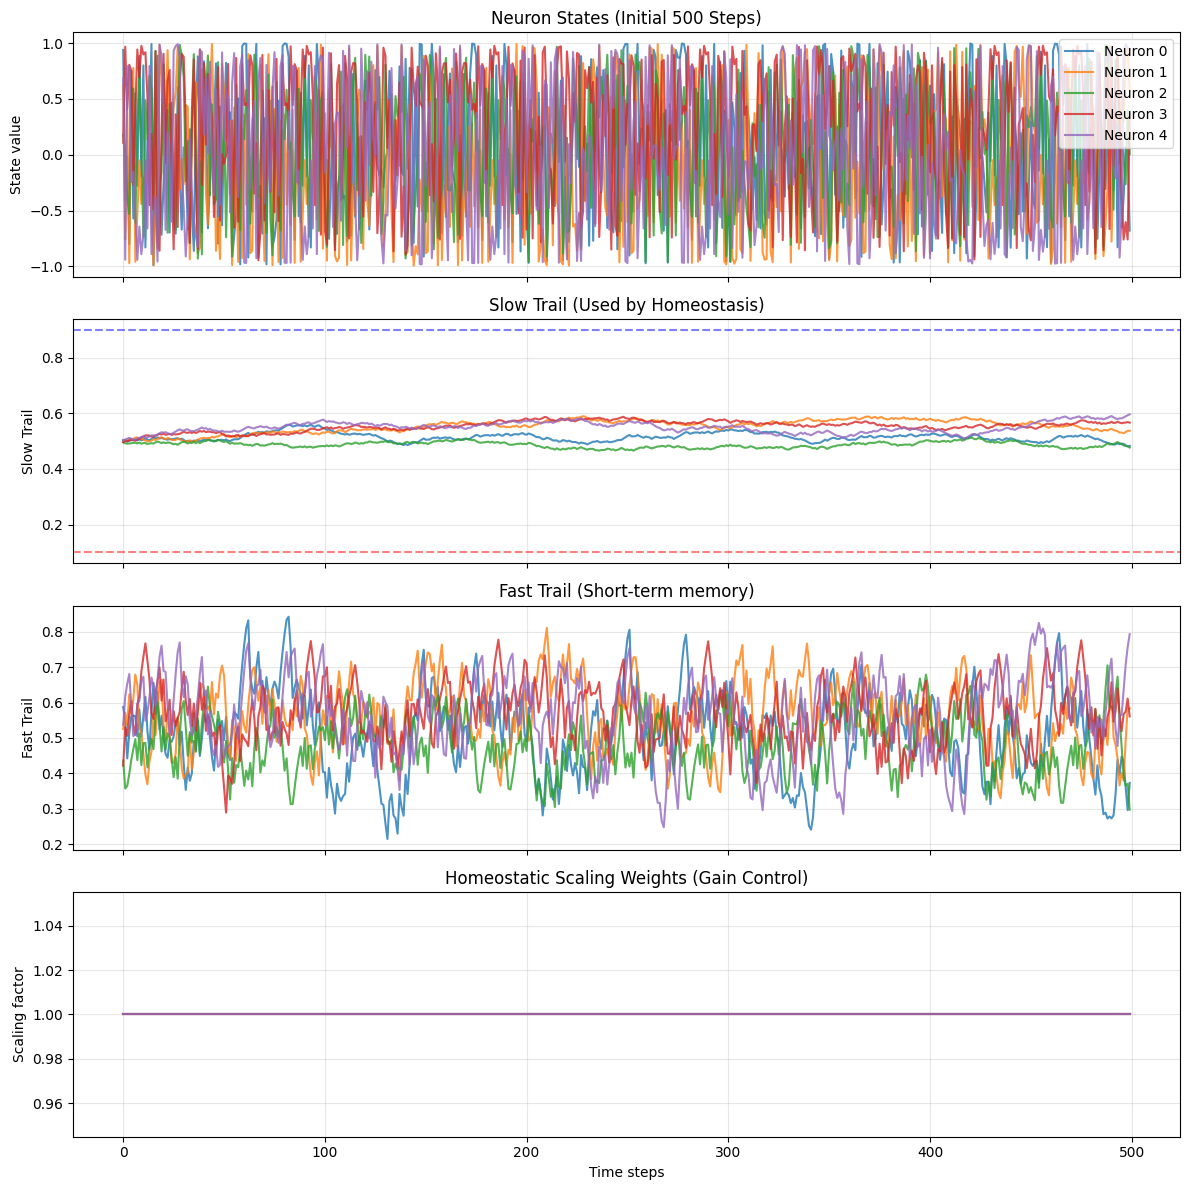

In [4]:
# 3. Plot initial dynamics (first 500 steps)
neurons_to_plot = [0, 1, 2, 3, 4]
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# States
for n in neurons_to_plot:
    axes[0].plot(states_first_500[:, n], label=f"Neuron {n}", alpha=0.8)
axes[0].set_ylabel("State value")
axes[0].set_title("Neuron States (Initial 500 Steps)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Slow Trail
for n in neurons_to_plot:
    axes[1].plot(slow_trail_first_500[:, n], alpha=0.8)
axes[1].axhline(0.1, color="red", linestyle="--", alpha=0.5, label="Low Limit (0.1)")
axes[1].axhline(0.9, color="blue", linestyle="--", alpha=0.5, label="High Limit (0.9)")
axes[1].set_ylabel("Slow Trail")
axes[1].set_title("Slow Trail (Used by Homeostasis)")
axes[1].grid(True, alpha=0.3)

# Fast Trail
for n in neurons_to_plot:
    axes[2].plot(fast_trail_first_500[:, n], alpha=0.8)
axes[2].set_ylabel("Fast Trail")
axes[2].set_title("Fast Trail (Short-term memory)")
axes[2].grid(True, alpha=0.3)

# Scaling
for n in neurons_to_plot:
    axes[3].plot(scaling_first_500[:, n], alpha=0.8)
axes[3].set_ylabel("Scaling factor")
axes[3].set_xlabel("Time steps")
axes[3].set_title("Homeostatic Scaling Weights (Gain Control)")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

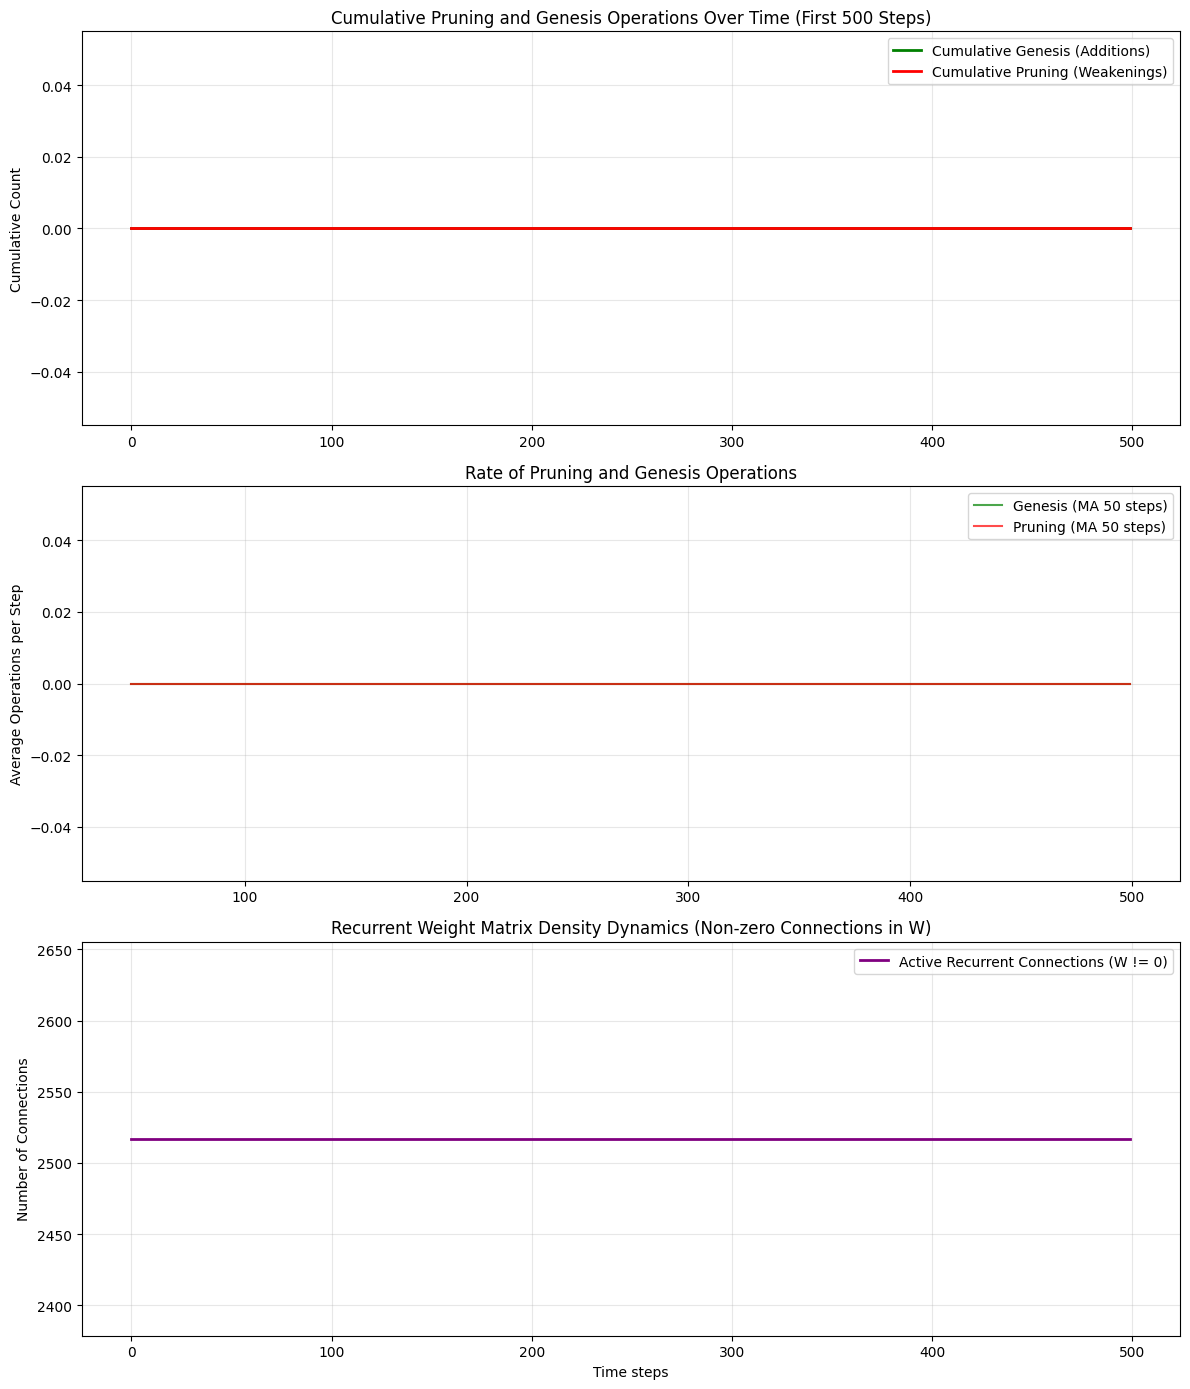

In [5]:
# 4. Plot the pruning, genesis, and active connection count over time (first 500 steps)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14))

# Plot cumulative operations
ax1.plot(np.cumsum(genesis_ops), label="Cumulative Genesis (Additions)", color="green", linewidth=2)
ax1.plot(np.cumsum(pruning_ops), label="Cumulative Pruning (Weakenings)", color="red", linewidth=2)
ax1.set_ylabel("Cumulative Count")
ax1.set_title("Cumulative Pruning and Genesis Operations Over Time (First 500 Steps)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot moving average of operations (to see stability/density)
window_size = 50
def moving_average(a, n=window_size):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

ma_genesis = moving_average(genesis_ops)
ma_pruning = moving_average(pruning_ops)
steps_ma = np.arange(window_size - 1, train_len)

ax2.plot(steps_ma, ma_genesis, label=f"Genesis (MA {window_size} steps)", color="green", alpha=0.7)
ax2.plot(steps_ma, ma_pruning, label=f"Pruning (MA {window_size} steps)", color="red", alpha=0.7)
ax2.set_ylabel("Average Operations per Step")
ax2.set_title("Rate of Pruning and Genesis Operations")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot active connections count in W
ax3.plot(non_zero_connections, label="Active Recurrent Connections (W != 0)", color="purple", linewidth=2)
ax3.set_xlabel("Time steps")
ax3.set_ylabel("Number of Connections")
ax3.set_title("Recurrent Weight Matrix Density Dynamics (Non-zero Connections in W)")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()